# Proyek Akhir: Prediksi Mahasiswa Dropout

- Nama: Monica Dyah Pudyowati
- Email: monicadyah.md14@gmail.com
- Id Dicoding: monicadyp

## Business Understanding

**Permasalahan Bisnis:**
Tingkat *dropout* (putus studi) mahasiswa yang tinggi berdampak negatif pada reputasi institusi dan stabilitas finansial perusahaan. Institusi perlu mendeteksi lebih awal mahasiswa mana yang berisiko tinggi untuk *dropout* agar intervensi akademik dapat dilakukan tepat waktu.

**Objektif:**
Membangun model *machine learning* klasifikasi untuk memprediksi probabilitas seorang mahasiswa akan *dropout* atau lulus, berdasarkan data demografi, performa akademik, dan latar belakang ekonomi.

**Rencana Teknologi:**
- **Bahasa:** Python
- **Library:** Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn
- **Algoritma:** Random Forest Classifier
- **Deployment & Dashboard:** Joblib (untuk ekspor model) dan Looker Studio untuk visualisasi bisnis.

## Persiapan

### Menyiapkan library yang dibutuhkan

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('data.csv', sep=';')

print(df.head())
print(df.info())
print(df['Status'].value_counts())

   Marital_status  Application_mode  Application_order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime_evening_attendance  Previous_qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous_qualification_grade  Nacionality  Mothers_qualification  \
0                         122.0            1                     19   
1                         160.0            1                      1   
2                         122.0            1   

## Data Understanding

Tahap ini bertujuan untuk melakukan identifikasi awal serta mencari pola dan insight dari dataset melalui proses Exploratory Data Analysis (EDA). Akan memeriksa missing value, statistik deskriptif, dan memvisualisasikan hubungan antar fitur.

       Marital_status  Application_mode  Application_order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime_evening_attendance  Previous_qualification  \
count                 4424.000000             4424.000000   
mean                     0.890823                4.577758   
std                      0.311897               10.216592   
min                      0.000000                1.000000   
25%                

/tmp/ipykernel_1993/1099437905.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


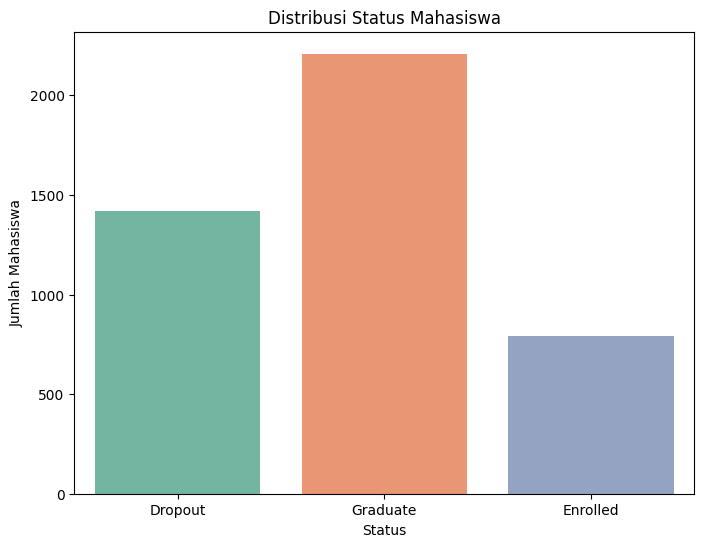

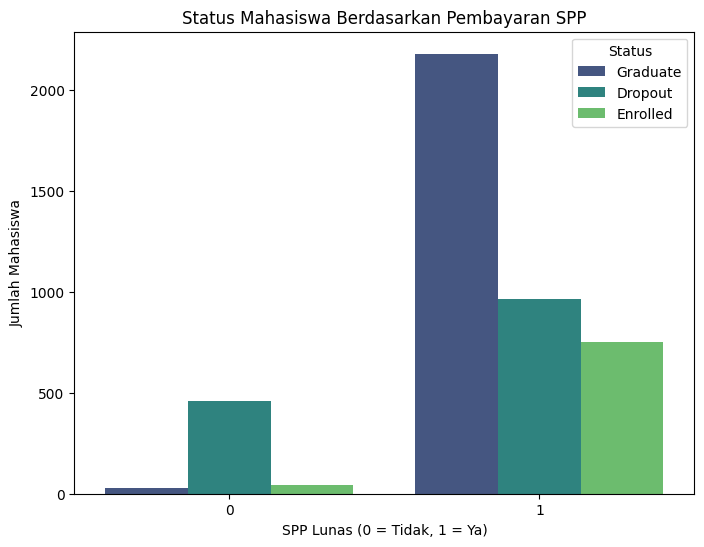

In [3]:
print(df.describe())

print("\nJumlah Missing Value per Kolom:")
print(df.isnull().sum())

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', palette='viridis')
plt.title('Status Mahasiswa Berdasarkan Pembayaran SPP')
plt.xlabel('SPP Lunas (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Mahasiswa')
plt.legend(title='Status')
plt.show()

## Data Preparation / Preprocessing

Data perlu ditransformasi menjadi format numerik berskala agar algoritma bisa memprosesnya dengan optimal. Langkah ini meliputi pemisahan variabel target, encoding label teks ke dalam format numerik (Label Encoding), pembagian dataset menjadi data latih dan data uji, serta standarisasi skala fitur numerik (Scaling).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df.drop('Status', axis=1)
y = df['Status']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Class mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Class mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


## Modeling

Pada tahap ini akan mengembangkan model klasifikasi untuk memprediksi probabilitas siswa yang berisiko keluar atau lulus. Hal ini bisa menggunakan algoritma Random Forest karena algoritma ini memadukan hasil prediksi dari sekumpulan Decision Tree sehingga performanya lebih kuat.

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

print(f"Parameter terbaik: {grid_search.best_params_}")

Parameter terbaik: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


## Evaluation

Tahap evaluasi bertujuan untuk mengukur performa prediksi dari model yang telah dilatih. Evaluasi untuk masalah klasifikasi multiclass dapat dilakukan menggunakan Confusion Matrix dan metrik klasifikasi utama yang mencakup Accuracy, Precision, Recall, dan F1-score.

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.85      0.77      0.81       316
    Enrolled       0.49      0.30      0.38       151
    Graduate       0.76      0.92      0.83       418

    accuracy                           0.76       885
   macro avg       0.70      0.67      0.67       885
weighted avg       0.75      0.76      0.75       885



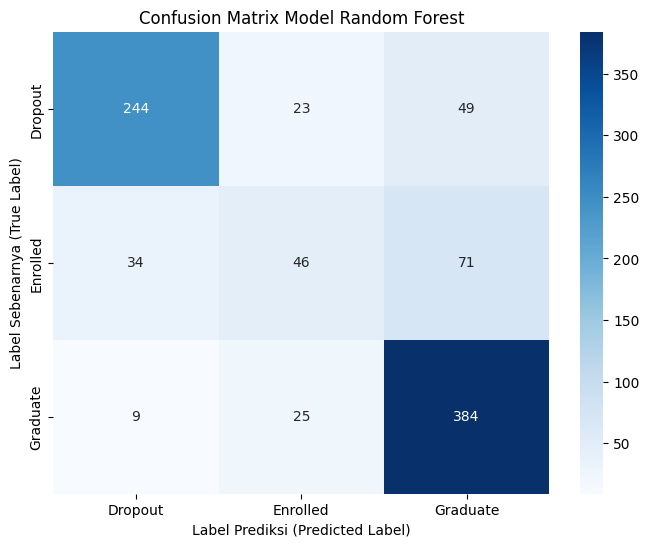

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix Model Random Forest')
plt.ylabel('Label Sebenarnya (True Label)')
plt.xlabel('Label Prediksi (Predicted Label)')
plt.show()

/tmp/ipykernel_1993/2696157221.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importances.head(10), palette='viridis')


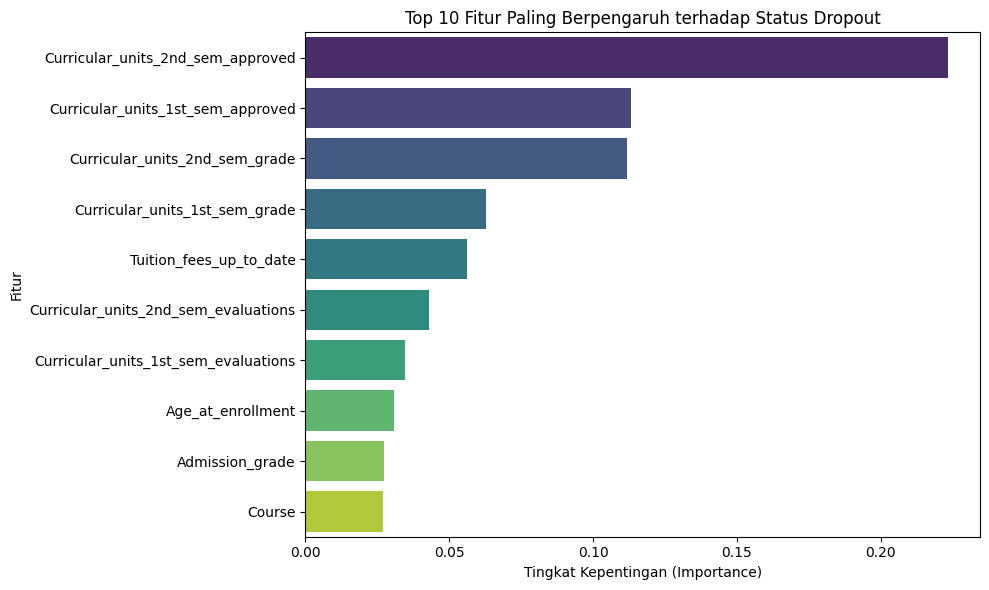

In [9]:
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importances.head(10), palette='viridis')
plt.title('Top 10 Fitur Paling Berpengaruh terhadap Status Dropout')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## Menyimpan Model

In [12]:
joblib.dump(best_rf_model, 'model_random_forest_terbaik.joblib')

print("Model berhasil disimpan sebagai 'model_random_forest_terbaik.joblib'")

Model berhasil disimpan sebagai 'model_random_forest_terbaik.joblib'


## Ekspor Data Bersih untuk Dashboard

In [13]:
df.to_csv('data_mahasiswa_bersih.csv', index=False)

## Kesimpulan dan Action Items

**Kesimpulan:**
Berdasarkan evaluasi, model Random Forest dengan hyperparameter tuning berhasil memprediksi status mahasiswa dengan akurasi yang baik. Dari visualisasi Feature Importances, ditemukan bahwa faktor utama yang paling memicu mahasiswa melakukan dropout berkaitan erat dengan performa akademik mereka. Tiga fitur yang paling berpengaruh adalah tingkat kelulusan mata kuliah di semester 2 (`Curricular_units_2nd_sem_approved`), tingkat kelulusan mata kuliah di semester 1 (`Curricular_units_1st_sem_approved`), dan nilai rata-rata di semester 2 (`Curricular_units_2nd_sem_grade`).

**Rekomendasi Action Items:**
1. **Sistem Peringatan Dini (Early Warning System):** Mengintegrasikan model ini ke dalam sistem akademik untuk secara otomatis menandai mahasiswa berisiko tinggi.
2. **Program Bimbingan Akademik Intensif:** Memberikan konseling proaktif bagi mahasiswa yang memiliki tingkat kelulusan mata kuliah atau nilai (grade) yang rendah sejak semester 1, sebelum mereka memasuki pertengahan semester 2.
3. **Evaluasi Kurikulum:** Mengkaji ulang beban tugas atau tingkat kesulitan pada mata kuliah di semester awal jika ditemukan tren penurunan nilai yang drastis secara massal.

---
## Business Dashboard
Dashboard interaktif telah dibuat untuk memonitori performa akademik mahasiswa secara real-time.

**Tautan Dashboard:** https://datastudio.google.com/reporting/b25da8bc-56e1-4e5a-9b0f-ec6f3881a018 

**Tautan Live Streamlit App:** [Coba Aplikasi Prediksi Online](https://prediksi-mahasiswa-dropout.streamlit.app/)